In [1]:
import os
import sys
import numpy as np
cwd = os.getcwd()
src_dir = os.path.join(cwd, '..', 'src')
sys.path.append(src_dir)
from dqc.dqc import DQCPipeline
from etl.etl import ETL

In [2]:
dqc = DQCPipeline()
etl = ETL()
data = etl.extract('https://www.kaggle.com/competitions/competitive-data-science-predict-future-sales')
report = dqc.render_report(val_rep=dqc.validation_report(data), stats_rep=dqc.statistics_report(data))

Skipping, found downloaded files in ".\competitive-data-science-predict-future-sales" (use force=True to force download)


INFO:etl.etl:Data extracted succesfully - 2025-09-09 10:13:29.092952
INFO:decorators.exec_time:Function _check_missing_values took 0.1953 seconds to execute
INFO:decorators.exec_time:Function _check_unique_values took 0.4852 seconds to execute
INFO:decorators.exec_time:Function _check_relationships took 0.3417 seconds to execute
INFO:decorators.exec_time:Function _check_duplicates took 1.0412 seconds to execute
INFO:decorators.exec_time:Function _check_outliers took 0.9544 seconds to execute
INFO:decorators.exec_time:Function _check_statistics took 0.7175 seconds to execute


# 1. DQC

In [3]:
report['validation_report']['missings']

missings_percentage
table_name        column_name                            
items             item_name                           0.0
                  item_id                             0.0
                  item_category_id                    0.0
item_categories   item_category_name                  0.0
                  item_category_id                    0.0
sales_train       date                                0.0
                  date_block_num                      0.0
                  shop_id                             0.0
                  item_id                             0.0
                  item_price                          0.0
                  item_cnt_day                        0.0
sample_submission ID                                  0.0
                  item_cnt_month                      0.0
shops             shop_name                           0.0
                  shop_id                             0.0
test              ID                                  0.0
                  shop_id                             0.0
                  item_id                             0.0

- No missing values over all tables

In [4]:
report['validation_report']['duplicates']

,duplicated_rows
items,0
item_categories,0
sales_train,6
sample_submission,0
shops,0
test,0


- We can see only 6 fully duplicated rows in *sales_train* which I assume we can reasonably drop

In [5]:
report['validation_report']['uniques']

unique_values
table_name        column_name                      
items             item_name                   22170
                  item_id                     22170
                  item_category_id               84
item_categories   item_category_name             84
                  item_category_id               84
sales_train       date                         1034
                  date_block_num                 34
                  shop_id                        60
                  item_id                     21807
                  item_price                  19993
                  item_cnt_day                  198
sample_submission ID                         214200
                  item_cnt_month                  1
shops             shop_name                      60
                  shop_id                        60
test              ID                         214200
                  shop_id                        42
                  item_id                      5100

- Data doesn't seem to be sparsed (don't pay attention at only 1 unique value in *item_cnt_month* - it's just sample_submission ^-^)

In [6]:
report['validation_report']['datatypes']

current_dtype inferred_dtype is_mixed  \
table_name        column_name                                                
item_categories   item_category_name        object         object    False   
                  item_category_id           int64          int64    False   
items             item_name                 object         object    False   
                  item_id                    int64          int64    False   
                  item_category_id           int64          int64    False   
sales_train       item_cnt_day             float64        float64    False   
                  item_price               float64        float64    False   
                  item_id                    int64          int64    False   
                  date_block_num             int64          int64    False   
                  date                      object         object    False   
                  shop_id                    int64          int64    False   
sample_submission ID                         int64          int64    False   
                  item_cnt_month           float64        float64    False   
shops             shop_name                 object         object    False   
                  shop_id                    int64          int64    False   
test              shop_id                    int64          int64    False   
                  ID                         int64          int64    False   
                  item_id                    int64          int64    False   

                                     suggested_dtype  
table_name        column_name                         
item_categories   item_category_name          object  
                  item_category_id              int8  
items             item_name                   object  
                  item_id                      int16  
                  item_category_id              int8  
sales_train       item_cnt_day               float32  
                  item_price                 float64  
                  item_id                      int16  
                  date_block_num                int8  
                  date                      category  
                  shop_id                       int8  
sample_submission ID                           int32  
                  item_cnt_month             float32  
shops             shop_name                   object  
                  shop_id                       int8  
test              shop_id                       int8  
                  ID                           int32  
                  item_id                      int16

- Most important thing to be admited is that there are no mixed types, though we can see that suggested types differ a little bit from original ones, which means we can downcast some numeric features to reduce memory usage

In [7]:
report['validation_report']['relationships']

,relation,left_only,intersect,right_only
0,"items, item_categories ON item_category_id",0,84,0
1,"items, sales_train ON item_id",363,21807,0
2,"items, test ON item_id",17070,5100,0
3,"sales_train, shops ON shop_id",0,60,0
4,"sales_train, test ON item_id",17070,4737,363
5,"sales_train, test ON shop_id",18,42,0
6,"sample_submission, test ON ID",0,214200,0
7,"shops, test ON shop_id",18,42,0


Well, there are some interesting observations on overlaps and orphans that have to be addmited:
- One of the most important things is that we have 363 items which are not present in *sales_train*
- There are 17070 which do not appear in *test*
- 17070 items in *sales_train* are not present in *test* and 363 items in *test* which do not appear in *sales_train*
- We have 18 shops in *sales_train* which are not in *test*
- 18 shops never appear in *test*

Some general conclusions:
- Dataset is mostly clear, except for 363 items which have never been mentioned *sales_train*
- Prediction  can be sort of limited due to so called cold-start problem: some items and shops are presented in *sales_train* but don't appear in *test* and vise versa

Some assumptions on how to handle items present in *test* but not present in *sales_train*:
- Simply drop rows: bad approach
- Create a binary feature, "flag": quite a good approach
- Initialize predictions as zeros: bad approach

In [44]:
test = data['test']
train = data['sales_train']
train_items = set(train['item_id'].values)
test['prev_seen'] = test['item_id'].map(lambda x: x in train_items)
test


,ID,shop_id,item_id,prev_seen
0,0,5,5037,True
1,1,5,5320,False
2,2,5,5233,True
3,3,5,5232,True
4,4,5,5268,False
...,...,...,...,...
214195,214195,45,18454,True
214196,214196,45,16188,True
214197,214197,45,15757,True
214198,214198,45,19648,True


- Such a way we create a binary feature *prev_seen* to mark items used for training (True flag) and whose unseen (False Flag)

In [8]:
report['statistics_report']['statistics']

count           mean           std  \
table_name        column_name                                                
items             item_id             22170.0   11084.500000   6400.072070   
                  item_category_id    22170.0      46.290753     15.941486   
item_categories   item_category_id       84.0      41.500000     24.392622   
sales_train       date_block_num    2935849.0      14.569911      9.422988   
                  shop_id           2935849.0      33.001728     16.226973   
                  item_id           2935849.0   10197.227057   6324.297354   
                  item_price        2935849.0     890.853233   1729.799631   
                  item_cnt_day      2935849.0       1.242641      2.618834   
sample_submission ID                 214200.0  107099.500000  61834.358168   
                  item_cnt_month     214200.0       0.500000      0.000000   
shops             shop_id                60.0      29.500000     17.464249   
test              ID                 214200.0  107099.500000  61834.358168   
                  shop_id            214200.0      31.642857     17.561933   
                  item_id            214200.0   11019.398627   6252.644590   

                                     min       1%       25%       50%  \
table_name        column_name                                           
items             item_id            0.0   221.69   5542.25   11084.5   
                  item_category_id   0.0     7.00     37.00      40.0   
item_categories   item_category_id   0.0     0.83     20.75      41.5   
sales_train       date_block_num     0.0     0.00      7.00      14.0   
                  shop_id            0.0     2.00     22.00      31.0   
                  item_id            0.0   556.00   4476.00    9343.0   
                  item_price        -1.0     5.00    249.00     399.0   
                  item_cnt_day     -22.0     1.00      1.00       1.0   
sample_submission ID                 0.0  2141.99  53549.75  107099.5   
                  item_cnt_month     0.5     0.50      0.50       0.5   
shops             shop_id            0.0     0.59     14.75      29.5   
test              ID                 0.0  2141.99  53549.75  107099.5   
                  shop_id            2.0     2.00     16.00      34.5   
                  item_id           30.0   341.83   5381.50   11203.0   

                                          75%        99%       max  
table_name        column_name                                       
items             item_id            16626.75   21947.31   22169.0  
                  item_category_id      58.00      78.00      83.0  
item_categories   item_category_id      62.25      82.17      83.0  
sales_train       date_block_num        23.00      33.00      33.0  
                  shop_id               47.00      59.00      59.0  
                  item_id            15684.00   21979.00   22169.0  
                  item_price           999.00    5999.00  307980.0  
                  item_cnt_day           1.00       5.00    2169.0  
sample_submission ID                160649.25  212057.01  214199.0  
                  item_cnt_month         0.50       0.50       0.5  
shops             shop_id               44.25      58.41      59.0  
test              ID                160649.25  212057.01  214199.0  
                  shop_id               47.00      59.00      59.0  
                  item_id            16071.50   21961.01   22167.0

Here's some statistics provided, which may not make a lot sense for an average user, but there are some important observations for us:
- *item_price* and *item_cnt_day* have negative values
- *item_price* has extremely huge values: max = 307980.0 whereas 99% percentile is only 5999.00
- The same is about *item_cnt_day*: max = 2169.0 whereas 99% percentile is only 5.00

Better have a look at outliers report

In [9]:
report['statistics_report']['outliers']

Q1         Q3       IQR  \
table             column                                            
items             item_id            5542.25   16626.75   11084.5   
                  item_category_id     37.00      58.00      21.0   
item_categories   item_category_id     20.75      62.25      41.5   
sales_train       date_block_num        7.00      23.00      16.0   
                  shop_id              22.00      47.00      25.0   
                  item_id            4476.00   15684.00   11208.0   
                  item_price          249.00     999.00     750.0   
                  item_cnt_day          1.00       1.00       0.0   
sample_submission ID                53549.75  160649.25  107099.5   
                  item_cnt_month        0.50       0.50       0.0   
shops             shop_id              14.75      44.25      29.5   
test              ID                53549.75  160649.25  107099.5   
                  shop_id              16.00      47.00      31.0   
                  item_id            5381.50   16071.50   10690.0   

                                    lower_bound  upper_bound  \
table             column                                       
items             item_id              -11084.5      33253.5   
                  item_category_id          5.5         89.5   
item_categories   item_category_id        -41.5        124.5   
sales_train       date_block_num          -17.0         47.0   
                  shop_id                 -15.5         84.5   
                  item_id              -12336.0      32496.0   
                  item_price             -876.0       2124.0   
                  item_cnt_day              1.0          1.0   
sample_submission ID                  -107099.5     321298.5   
                  item_cnt_month            0.5          0.5   
shops             shop_id                 -29.5         88.5   
test              ID                  -107099.5     321298.5   
                  shop_id                 -30.5         93.5   
                  item_id              -10653.5      32106.5   

                                    outliers_percentage  min_val   max_val  \
table             column                                                     
items             item_id                      0.000000      0.0   22169.0   
                  item_category_id             0.717185      0.0      83.0   
item_categories   item_category_id             0.000000      0.0      83.0   
sales_train       date_block_num               0.000000      0.0      33.0   
                  shop_id                      0.000000      0.0      59.0   
                  item_id                      0.000000      0.0   22169.0   
                  item_price                   8.820004     -1.0  307980.0   
                  item_cnt_day                10.439127    -22.0    2169.0   
sample_submission ID                           0.000000      0.0  214199.0   
                  item_cnt_month               0.000000      0.5       0.5   
shops             shop_id                      0.000000      0.0      59.0   
test              ID                           0.000000      0.0  214199.0   
                  shop_id                      0.000000      2.0      59.0   
                  item_id                      0.000000     30.0   22167.0   

                                    1%_percentile  99%_percentile  
table             column                                           
items             item_id                  221.69        21947.31  
                  item_category_id           7.00           78.00  
item_categories   item_category_id           0.83           82.17  
sales_train       date_block_num             0.00           33.00  
                  shop_id                    2.00           59.00  
                  item_id                  556.00        21979.00  
                  item_price                 5.00         5999.00  
                  item_cnt_day               1.00  

We are actually not interested in those "outliers" in *item_category_id* but what really interests the most is *item_price* and *item_cnt_day* outliers:
- First of all outliers percentage was calculated based on IQR
- According to calculations we have 8.82% otliers in *item_price* with appropriate range [-876.0, 2124.0] (prices can't actually be negative, thus we consider the range to be [0, 2124.0]). But the upper bound differes a lot from the 99 percentile which is confusing about outliers (whether to catch them based on IQR or 98% range). Though we have items with extremely high price which can also be important information for us in future.
- *item_cnt_day* has more then 10% outliers, and based on IQR the only appropriate value is 1 item sold per day which doesn't seem realistic. Based on 99 percentile, the upper bound is 5 items per day which is I guess more preferable.

Assumptions:
- At this point I think detecting outliers based on 98 percentile middle range is much more preferable than IQR
- I'm still not sure whether we have to drop those outliers

# 2. ETL
Here comes data transformation and I do really have initial ideas on what to do:
1) Drop duplicates (keep the first mentioned respectively)
2) May be we can try downcasting some numeric features to reduce memory usage (the dataset is for real heavy enough)
3) Validate *item_price*, i.e. limit values. Prices are not allowed to be negative, though extremely high prices are not a good thing. Thus, I guess leaving only [0, 5999.0] prices range
4) Something interesting is going on with *item_cnt_day* and we could think that sales can not be negative, but actually items sold per day value less than zero can mean refund or something like that, it's to be explored(we'll decide what to do later on)
5) We can probably benefit from unifying(deleteing special symbols, lowercaseing and striping) categorical features(e.g. *shop_name*)
6) We can obviously cast *date* to datetime
7) Need to investigate if shops have similar names but different ids so as to combine them

In [10]:
for t_name, df in data.items():
    mem_usage_bytes = df.memory_usage(deep=True).sum()
    mem_usage_mb = mem_usage_bytes / (1024 ** 2)
    print(f"{t_name} uses {mem_usage_bytes} bytes and {mem_usage_mb} MB")

items uses 4783654 bytes and 4.562047958374023 MB
item_categories uses 13355 bytes and 0.012736320495605469 MB
sales_train uses 290649183 bytes and 277.18466091156006 MB
sample_submission uses 3427332 bytes and 3.2685585021972656 MB
shops uses 9977 bytes and 0.009514808654785156 MB
test uses 5140932 bytes and 4.902774810791016 MB


- *sales_train* uses a huge amount of memory, and I would love to reduce its usage

In [11]:
import pandas as pd
from typing import Dict
def reduce_memory(tables:Dict[str, pd.DataFrame], dtype_table: pd.DataFrame) -> Dict[str, pd.DataFrame]:
    for table_name, df in data.items():
        sub = dtype_table.loc[table_name]
        for col, dtype in sub['suggested_dtype'].items():
            if col in df.columns and df[col].dtype != dtype:
                try:
                    df[col] = df[col].astype(dtype)
                except Exception as e:
                    print(f"Could not cast {table_name}.{col} to {dtype}: {e}")
    return data

In [12]:
for t_name, df in data.items():
    mem_usage_bytes = df.memory_usage(deep=True).sum()
    mem_usage_mb = mem_usage_bytes / (1024 ** 2)
    print(f"{t_name} uses {mem_usage_bytes} bytes and {mem_usage_mb} MB")

items uses 4783654 bytes and 4.562047958374023 MB
item_categories uses 13355 bytes and 0.012736320495605469 MB
sales_train uses 290649183 bytes and 277.18466091156006 MB
sample_submission uses 3427332 bytes and 3.2685585021972656 MB
shops uses 9977 bytes and 0.009514808654785156 MB
test uses 5140932 bytes and 4.902774810791016 MB


- Seems like we could significantly reduce memory usage by *sales_train* (277MB -> 50MB) and *test* (4.9 MB -> 1.43MB)
- We can organize algorithm as *reduce_memory* function for futher use in pipes

In [13]:
def reduce_memory(df: pd.DataFrame, dtype_table: pd.DataFrame, table_name: str) -> pd.DataFrame:
    sub = dtype_table.loc[table_name]
    for col, dtype in sub['suggested_dtype'].items():
        if col in df.columns and df[col].dtype != dtype and col != 'date':
            try:
                df[col] = df[col].astype(dtype)
            except Exception as e:
                print(f"Could not cast {col} to {dtype}: {e}")
    return df

Now let's explore *item_cnt_day* for the possibility to be returns

In [14]:
neg_sales = data['sales_train'][data['sales_train']['item_cnt_day'] < 0]
print(f"Negative sales count: {len(neg_sales)}")
neg_sales['item_cnt_day'].value_counts()

Negative sales count: 7356


item_cnt_day
-1.0     7252
-2.0       78
-3.0       14
-5.0        4
-4.0        3
-6.0        2
-22.0       1
-16.0       1
-9.0        1
Name: count, dtype: int64

In [15]:
neg_sales[['date', 'shop_id', 'item_id', 'item_cnt_day']].head(10)

,date,shop_id,item_id,item_cnt_day
2,05.01.2013,25,2552,-1.0
148,23.01.2013,25,2321,-1.0
175,07.01.2013,25,2199,-1.0
807,02.01.2013,25,2330,-1.0
1041,13.01.2013,25,5034,-1.0
1193,02.01.2013,25,5651,-1.0
1674,07.01.2013,25,4093,-1.0
1825,02.01.2013,25,4249,-1.0
2411,14.01.2013,24,1628,-1.0
3216,08.01.2013,24,20948,-1.0


In [16]:
sample = neg_sales.iloc[0]
similar_sales = data['sales_train'][
    (data['sales_train']['item_id'] == sample['item_id']) &
    (data['sales_train']['shop_id'] == sample['shop_id'])
]
similar_sales[['date', 'item_cnt_day']]

,date,item_cnt_day
1,03.01.2013,1.0
2,05.01.2013,-1.0


correlation:  0.8272851354655943


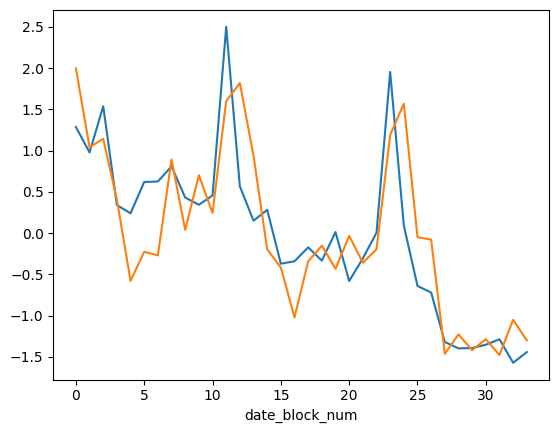

In [17]:
import matplotlib.pyplot as plt

sales_train = data['sales_train']
sales_train_cnt = sales_train[sales_train["item_cnt_day"]>0]
sales_train_ncnt = sales_train[sales_train["item_cnt_day"]<0]

normalize = lambda df: (df-df.mean())/df.std()

pos = normalize(sales_train_cnt.groupby("date_block_num").date.count())
neg = normalize(sales_train_ncnt.groupby("date_block_num").date.count())
pos.plot()
neg.plot()

print("correlation: ", np.corrcoef(pos, neg)[0,1])

- Since the correlation coefficient between negative sales and positive is quite high, we can assume negatives to be refunds generally. Though we can not make such conclusions based only on correlation. Better conduct a much deeper investigation.

In [18]:
import pandas as pd
from collections import deque

def match_group(df):
    df = df.sort_values('date').copy()
    pool = deque()
    will_be_returned = set()
    return_candidate = set()
    pairs_records = []

    for idx, row in df.iterrows():
        qty = row['item_cnt_day']
        if qty > 0:
            pool.append([idx, qty])
        elif qty < 0:
            need = -qty
            while need and pool:
                p_idx, p_qty = pool[0]
                take = min(p_qty, need)
                pairs_records.append({
                    'purchase_idx': p_idx,
                    'return_idx': idx,
                    'matched_qty': take,
                })
                if take == p_qty:
                    pool.popleft()
                    will_be_returned.add(p_idx)
                else:
                    pool[0][1] -= take
                    will_be_returned.add(p_idx)
                need -= take
            if -row['item_cnt_day'] > 0:
                return_candidate.add(idx)

    df['will_be_returned'] = df.index.isin(will_be_returned)
    df['return_candidate'] = df.index.isin(return_candidate)
    pairs_df = pd.DataFrame(pairs_records)

    return df, pairs_df

- The idea of such an approach is that we might have partial refunds: one return can consume multiple purchases; one purchase can be partially consumed by multiple returns. Thus, we'll be able to detect returns and errors much more accurate (at least I believe so). Plus by using queue it's able to preserve linking purchases that on or before the return only. Such a way we make sure that a refund did not happen before item was purchased (avoid additional errors).

In [19]:
df_flagged, pairs_df = match_group(sales_train)

display(df_flagged)
display(pairs_df)

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,will_be_returned,return_candidate
16164,01.01.2013,0,28,11613,1499.0,1.0,True,False
101474,01.01.2013,0,51,10283,667.0,1.0,True,False
10197,01.01.2013,0,19,2828,499.0,1.0,True,False
101457,01.01.2013,0,51,10390,150.0,1.0,True,False
101455,01.01.2013,0,51,10591,110.0,1.0,True,False
...,...,...,...,...,...,...,...,...
2263531,31.12.2014,23,10,15784,195.0,1.0,False,False
2238358,31.12.2014,23,31,18624,499.0,1.0,False,False
2238360,31.12.2014,23,31,18622,169.0,1.0,False,False
2210313,31.12.2014,23,59,9412,299.0,1.0,False,False


,purchase_idx,return_idx,matched_qty
0,16164,10621,1.0
1,101474,82413,1.0
2,10197,49083,1.0
3,101457,105843,1.0
4,101455,7894,1.0
...,...,...,...
7501,217532,2259297,1.0
7502,217532,2269963,1.0
7503,217534,2257541,1.0
7504,192214,2269685,1.0


In [20]:
df_flagged[df_flagged['return_candidate']]

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,will_be_returned,return_candidate
10621,01.01.2013,0,19,13086,1499.0,-1.0,False,True
82413,01.01.2013,0,54,3429,2799.0,-1.0,False,True
49083,01.01.2013,0,18,6724,299.5,-1.0,False,True
105843,01.01.2013,0,37,9601,849.0,-1.0,False,True
7894,01.01.2013,0,19,20383,1229.0,-1.0,False,True
...,...,...,...,...,...,...,...,...
2259297,31.12.2014,23,15,2819,3199.0,-1.0,False,True
2269963,31.12.2014,23,16,2875,849.0,-1.0,False,True
2257541,31.12.2014,23,14,7806,1299.5,-1.0,False,True
2269685,31.12.2014,23,16,3735,3199.0,-1.0,False,True


In [21]:
df_flagged[df_flagged['will_be_returned']]

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,will_be_returned,return_candidate
16164,01.01.2013,0,28,11613,1499.0,1.0,True,False
101474,01.01.2013,0,51,10283,667.0,1.0,True,False
10197,01.01.2013,0,19,2828,499.0,1.0,True,False
101457,01.01.2013,0,51,10390,150.0,1.0,True,False
101455,01.01.2013,0,51,10591,110.0,1.0,True,False
...,...,...,...,...,...,...,...,...
118507,01.02.2013,1,47,20541,1199.0,2.0,True,False
217532,01.02.2013,1,31,990,99.0,2.0,True,False
217534,01.02.2013,1,31,991,99.0,1.0,True,False
192214,01.02.2013,1,31,13147,249.0,1.0,True,False


In [22]:
abs(len(sales_train[sales_train['item_cnt_day'] < 0]) - len(df_flagged[df_flagged['will_be_returned']]))


1169

- Such a way we have 1169 items that are definitely not refunds. We can even display them:

In [23]:
df_flagged[df_flagged['will_be_returned'] != True]

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,will_be_returned,return_candidate
10621,01.01.2013,0,19,13086,1499.0,-1.0,False,True
82413,01.01.2013,0,54,3429,2799.0,-1.0,False,True
49083,01.01.2013,0,18,6724,299.5,-1.0,False,True
105843,01.01.2013,0,37,9601,849.0,-1.0,False,True
7894,01.01.2013,0,19,20383,1229.0,-1.0,False,True
...,...,...,...,...,...,...,...,...
2263531,31.12.2014,23,10,15784,195.0,1.0,False,False
2238358,31.12.2014,23,31,18624,499.0,1.0,False,False
2238360,31.12.2014,23,31,18622,169.0,1.0,False,False
2210313,31.12.2014,23,59,9412,299.0,1.0,False,False


In [24]:
items = data['items']
items

,item_name,item_id,item_category_id
0,! ВО ВЛАСТИ НАВАЖДЕНИЯ (ПЛАСТ.) D,0,40
1,!ABBYY FineReader 12 Professional Edition Full...,1,76
2,***В ЛУЧАХ СЛАВЫ (UNV) D,2,40
3,***ГОЛУБАЯ ВОЛНА (Univ) D,3,40
4,***КОРОБКА (СТЕКЛО) D,4,40
...,...,...,...
22165,"Ядерный титбит 2 [PC, Цифровая версия]",22165,31
22166,Язык запросов 1С:Предприятия [Цифровая версия],22166,54
22167,Язык запросов 1С:Предприятия 8 (+CD). Хрустале...,22167,49
22168,Яйцо для Little Inu,22168,62


- As we see names have different caseing and some of them have some special symbols in the front or back

In [25]:
import re
items.loc[:, 'item_name'] = items['item_name'].str.lower()
com = re.compile(r'[^\w\s]+')
items.loc[:, 'item_name'] = [com.sub('',x) for x in items['item_name'].tolist()]
items.duplicated(subset='item_name').sum()

np.int64(71)

- Such a way we unified item names but there one problem reveals - we now have 71 duplicates, just droping them isn't a solution as we'll also loose ids

In [26]:
id_to_name = items.to_dict()["item_name"]
name_to_first_id = items.groupby("item_name").first().to_dict()["item_id"]
ids_to_id = {key: name_to_first_id[id_to_name[key]] for key in id_to_name.keys()}
keys = list(ids_to_id.keys())
for i in range (len(keys)):
    if ids_to_id[keys[i]] == keys[i]:
        del ids_to_id[keys[i]]

- This new ids will then be used in pipes

In [27]:
shops = data['shops']
shops

,shop_name,shop_id
0,"!Якутск Орджоникидзе, 56 фран",0
1,"!Якутск ТЦ ""Центральный"" фран",1
2,"Адыгея ТЦ ""Мега""",2
3,"Балашиха ТРК ""Октябрь-Киномир""",3
4,"Волжский ТЦ ""Волга Молл""",4
5,"Вологда ТРЦ ""Мармелад""",5
6,"Воронеж (Плехановская, 13)",6
7,"Воронеж ТРЦ ""Максимир""",7
8,"Воронеж ТРЦ Сити-Парк ""Град""",8
9,Выездная Торговля,9


In [28]:
shops['shop_name'] = shops['shop_name'].str.lower().apply(lambda x: com.sub('', x))
shops

,shop_name,shop_id
0,якутск орджоникидзе 56 фран,0
1,якутск тц центральный фран,1
2,адыгея тц мега,2
3,балашиха трк октябрькиномир,3
4,волжский тц волга молл,4
5,вологда трц мармелад,5
6,воронеж плехановская 13,6
7,воронеж трц максимир,7
8,воронеж трц ситипарк град,8
9,выездная торговля,9


- Did lowercasing and deleting special symbols in front
- Here we can see the almost the same shop names with different ids:

    -   0 - 57
    -   1 - 58
    -   39 - 40
    -   10 - 11


In [29]:
shop_ids = {
    0: 57,
    1: 58,
    39: 40,
    10:11
}

pipes = {
    "sales_train":[
        lambda table: table.replace({"shop_id" : shop_ids}),
        lambda table: table.replace({'item_id': ids_to_id}),
        lambda table: table[(0 < table['item_price']) & (table['item_price'] <= 5999.0)],
        lambda table: table[(0 <= table['item_cnt_day']) & (table['item_cnt_day'] <= 5)],
        lambda table: table[~table.duplicated(keep='first')],
        lambda table: reduce_memory(table, report['validation_report']['datatypes'], 'sales_train'),
        lambda table: table.assign(date=pd.to_datetime(table['date'], format='%d.%m.%Y'))
        ],
    "shops":[
        lambda table: table.replace({"shop_id": shop_ids}),
        lambda table: table.assign(shop_name = [com.sub('',x) for x in shops['shop_name'].tolist()]),
        lambda table: table.assign(city = table['shop_name'].str.split(" ").str[0]),

    ],
    'items':[
        lambda table: table.assign(item_name = table["item_name"].apply(lambda x: x.lower())),
        lambda table: table.assign(item_name = [com.sub('',x) for x in items['item_name'].tolist()]),
        lambda table: table.replace({"item_id": ids_to_id})
    ]
}

train, test = etl.load(url='https://www.kaggle.com/competitions/competitive-data-science-predict-future-sales',
                       pipes=pipes)

Skipping, found downloaded files in ".\competitive-data-science-predict-future-sales" (use force=True to force download)


INFO:etl.etl:Data extracted succesfully - 2025-09-09 10:17:13.164942
INFO:etl.etl:Data transformed successfully - 2025-09-09 10:17:13.164942
INFO:etl.etl:Pipes aplied sucessfully - 2025-09-09 10:17:17.416923
INFO:etl.etl:Tables merged successfully - 2025-09-09 10:17:19.781731
INFO:etl.etl:Data loaded successfully - 2025-09-09 10:17:19.794733
INFO:decorators.exec_time:Function load took 8.9977 seconds to execute


In [30]:
report = dqc.render_report(val_rep=dqc.validation_report({'train': train, 'test':test}),
                  stats_rep = dqc.statistics_report({'train': train, 'test':test}))

INFO:decorators.exec_time:Function _check_missing_values took 0.8516 seconds to execute
INFO:decorators.exec_time:Function _check_unique_values took 2.5097 seconds to execute
INFO:decorators.exec_time:Function _check_relationships took 3.2420 seconds to execute
INFO:decorators.exec_time:Function _check_duplicates took 3.7603 seconds to execute
INFO:decorators.exec_time:Function _check_outliers took 1.1466 seconds to execute
INFO:decorators.exec_time:Function _check_statistics took 0.9554 seconds to execute


In [31]:
train

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,item_name,item_category_id,item_category_name,shop_name,city
0,2013-01-02,0,59,22154,999.00,1.0,явление 2012 bd,37,Кино - Blu-Ray,ярославль тц альтаир,ярославль
1,2013-01-03,0,25,2552,899.00,1.0,deep purple the house of blue light lp,58,Музыка - Винил,москва трк атриум,москва
2,2013-01-06,0,25,2554,1709.05,1.0,deep purple who do you think we are lp,58,Музыка - Винил,москва трк атриум,москва
3,2013-01-15,0,25,2555,1099.00,1.0,deep purple 30 very best of 2cd фирм,56,Музыка - CD фирменного производства,москва трк атриум,москва
4,2013-01-10,0,25,2564,349.00,1.0,deep purple perihelion live in concert dvd кир,59,Музыка - Музыкальное видео,москва трк атриум,москва
...,...,...,...,...,...,...,...,...,...,...,...
3127514,2015-10-10,33,25,7409,299.00,1.0,va nu jazz selection digipack,55,Музыка - CD локального производства,москва трк атриум,москва
3127515,2015-10-09,33,25,7460,299.00,1.0,va the golden jazz collection 1 2cd,55,Музыка - CD локального производства,москва трк атриум,москва
3127516,2015-10-14,33,25,7459,349.00,1.0,va the best of the 3 tenors,55,Музыка - CD локального производства,москва трк атриум,москва
3127517,2015-10-22,33,25,7440,299.00,1.0,va relax collection planet mp3 mp3cd jewel,57,Музыка - MP3,москва трк атриум,москва


In [32]:
test

,ID,shop_id,item_id,item_name,item_category_id,item_category_name,shop_name,city
0,0,5,5037,nhl 15 ps3 русские субтитры,19.0,Игры - PS3,вологда трц мармелад,вологда
1,1,5,5320,one direction made in the am,55.0,Музыка - CD локального производства,вологда трц мармелад,вологда
2,2,5,5233,need for speed rivals essentials ps3 русская в...,19.0,Игры - PS3,вологда трц мармелад,вологда
3,3,5,5232,need for speed rivals classics xbox 360 русска...,23.0,Игры - XBOX 360,вологда трц мармелад,вологда
4,4,5,5268,need for speed ps4 русская версия,20.0,Игры - PS4,вологда трц мармелад,вологда
...,...,...,...,...,...,...,...,...
224791,214195,45,18454,сб союз 55,55.0,Музыка - CD локального производства,самара тц паркхаус,самара
224792,214196,45,16188,настольная игра нано кёрлинг,64.0,Подарки - Настольные игры,самара тц паркхаус,самара
224793,214197,45,15757,новиков александр новая коллекция,55.0,Музыка - CD локального производства,самара тц паркхаус,самара
224794,214198,45,19648,терем теремок сбмф регион,40.0,Кино - DVD,самара тц паркхаус,самара
